## Exercício Prático — Aula 01

#### SETUP DO EXERCÍCIO

In [3]:
# Carregando as bibliotecas, a base a fazendo a cópia
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Caminho relativo: sobe uma pasta (../) e entra em base/
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
df = pd.read_excel("../base/base_vendas_supermercado.xlsx")

print(f"Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas")

Dataset carregado: 250 linhas x 12 colunas


In [10]:
# Criando á cópia para prática
np.random.seed(42)           # garante os resultados =
df_sujo = df.copy()          # NOVA BASE!

# 1. Inserindo o **NaN** - locais específicos
nan_config = {
    'Categoria':          14,   # 14 registros sem categoria
    'Preço Unitário':     12,   # 12 preços não registrados
    'Forma de Pagamento': 10,   # 10 pagamentos sem forma
    'Quantidade':          8,   # 8 quantidades ausentes
}
for coluna, qtd in nan_config.items():
    indices = np.random.choice(df_sujo.index, size=qtd, replace=False)
    df_sujo.loc[indices, coluna] = np.nan

# 2. Inserir duplicatas (simula importação dupla de planilha)
duplicatas = df_sujo.sample(n=12, random_state=7)
df_sujo = pd.concat([df_sujo, duplicatas], ignore_index=True)
df_sujo = df_sujo.sample(frac=1, random_state=3).reset_index(drop=True)

# Analise visual das alteraçãoe
print("=== Analize da Cópia Suja ===")
print(f"{'Métrica':<15} {'Original':>10} {'Sujo':>8}")
print("-" * 35)
print(f"{'Linhas':<15} {df.shape[0]:>10} {df_sujo.shape[0]:>8}")
print(f"{'Colunas':<15} {df.shape[1]:>10} {df_sujo.shape[1]:>8}")
print(f"{'Total de NaN':<15} {df.isnull().sum().sum():>10} {df_sujo.isnull().sum().sum():>8}")
print(f"{'Duplicatas':<15} {df.duplicated().sum():>10} {df_sujo.duplicated().sum():>8}")

=== Analize da Cópia Suja ===
Métrica           Original     Sujo
-----------------------------------
Linhas                 250      262
Colunas                 12       12
Total de NaN             0       47
Duplicatas               0       12


#### 1º - Qual coluna tem o **maior %** de valores ausentes? Calcular e Exibir.
Usando o df_sujo criado na aula.

In [12]:
# Percentual de NaN por coluna (só mostra colunas com NaN)
pct = (df_sujo.isnull().sum() / len(df_sujo) * 100).round(1)
pct_filtrado = pct[pct > 0].sort_values(ascending=False)

print("=== Valores Ausentes em % ===")
for coluna, pct in pct_filtrado.items():
    barras = '█' * int(pct / 2)
    print(f"  {coluna:<20} {pct:5.2f}% {barras}")

=== Valores Ausentes em % ===
  Categoria             6.10% ███
  Preço Unitário        4.60% ██
  Forma de Pagamento    3.80% █
  Quantidade            3.40% █


#### 2º - Preencha os NaN da coluna `'Forma de Pagamento'` com o valor `'Pix'` (simula uma decisão de negócio:<br> qualquer pagamento sem forma registrada foi via Pix) - Confirme que não há mais NaN.

In [55]:
df_filtro = df_sujo.copy()

moda_pgto = df_filtro['Forma de Pagamento'].mode()[0]
df_filtro['Forma de Pagamento'] = df_filtro['Forma de Pagamento'].fillna(moda_pgto)

print(f"Forma de Pagamento: {moda_pgto}")
print("NaN restantes:", df_filtro[['Forma de Pagamento']].isnull().sum().to_string())

Forma de Pagamento: Pix
NaN restantes: Forma de Pagamento    0


3º - Para a coluna `'Preço Unitário'`, em vez da mediana, use a **média por Categoria** para preencher os NaN.<br> Ou seja: cada produto deve ter seu NaN preenchido com a média dos outros produtos da mesma categoria.<br> Dica: `groupby + transform('mean')`.

In [104]:
media_cat = df_filtro['Preço Unitário'].median()

media_por_cat = df_filtro.groupby('Categoria')['Preço Unitário'].transform('mean')
df_filtro['Preço Unitário'] = df_filtro['Preço Unitário'].fillna(media_por_cat)
media_geral = df_filtro['Preço Unitário'].mean()

print(f"Média do 'Preço Unitário' por categoria")
print(df_filtro[["Categoria", "Preço Unitário"]].head(5).to_string())

Média do 'Preço Unitário' por categoria
    Categoria  Preço Unitário
0         NaN            7.02
1  Hortifruti            6.65
2  Laticínios           12.49
3     Limpeza           18.31
4     Higiene           15.89


4º - Verifique se existem duplicatas apenas considerando as colunas `['Data', 'Loja', 'Produto', 'Quantidade']`<br> (ignora o restante). Quantas encontrou?

In [111]:
# duplicated() retorna True para a 2ª ocorrência em diante
duplicatas_mask = df_filtro.duplicated()
linhas_dup = df_filtro[duplicatas_mask].head(5)
n = df_filtro.duplicated(subset=['Data','Loja','Produto','Quantidade']).sum()
print(f"Total de Duplicatas (subset): {n}")

Total de Duplicatas (subset): 12


5. Crie um gráfico de pizza mostrando a distribuição de **Forma de Pagamento** após a limpeza completa.

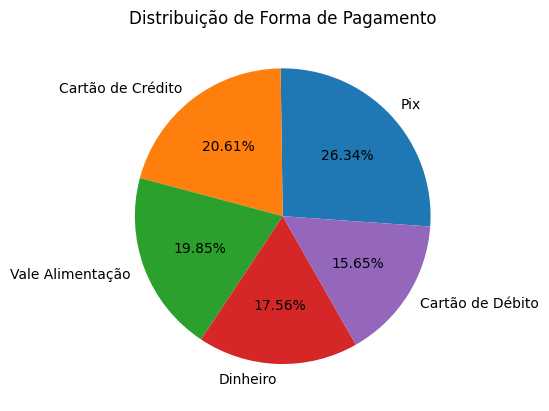

In [138]:
pag = df_filtro['Forma de Pagamento'].value_counts()
plt.pie(
    pag.values,
    labels=pag.index,
    autopct='%1.2f%%',
    labeldistance=1.1,
    startangle=-4,
)
plt.title('Distribuição de Forma de Pagamento')
plt.show()